In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from wannierberri import run
from wannierberri.grid import Grid

from wannierberri.system import System_PythTB
from wannierberri.calculators.static import DOS, Ohmic_FermiSea
from wannierberri.calculators.tabulate import TabulatorAll 
import ray
ray.init()


/home/stepan/work/Triangles/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-16 22:39:44,548	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-16 22:39:46,621	INFO worker.py:1918 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Python version:,3.12.12
Ray version:,2.48.0
Dashboard:,http://127.0.0.1:8265


In [ ]:
NK=100
system = System_PythTB(Haldane_ptb())
from wannierberri.models import Haldane_ptb, Chiral
calculators = {}

Efermi = np.linspace(-3, 3, 100)
calculators["dos"] = DOS(Efermi=Efermi, tetra=True)
calculators["ohmic"] = Ohmic_FermiSea(Efermi=Efermi, tetra=True)
calculators["tabulate"] = TabulatorAll(tabulators={})
grid = Grid(system, NK=100, NKFFT=10)

results = run(system, calculators=calculators, grid=grid)

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (7, 2, 2)
Real-space lattice:
 [[1.        0.        0.       ]
 [0.5       0.8660254 0.       ]
 [0.        0.        1.       ]]
Number of wannier functions: 2
Number of R points: 7
Recommended size of FFT grid [3 3 1]
Reading the system from PythTB finished successfully
Starting run()
Using the follwing calculators : 
############################################################

 'dos'  :  <wannierberri.calculators.static.DOS object at 0x7a0b0fd2a540>  : Density of states
 'ohmic'  :  <wannierberri.calculators.static.Ohmic_FermiSea object at 0x7a0a6c2f0980>  : Ohmic conductivity (:math:`S/m`)

        | With Fermi sea integral. Eq(31) in `Ref <https://www.nature.com/articles/s41524-021-00498-5>`__
        | Output: :math:`\sigma_{\alpha\beta} = e^2/\hbar \tau \int [dk] \partial_\beta v_\alpha f`for \tau=1fs| Instruction: :math:`j_\alpha = \sigma_{\alpha\beta} E_\beta`
 'tabulat

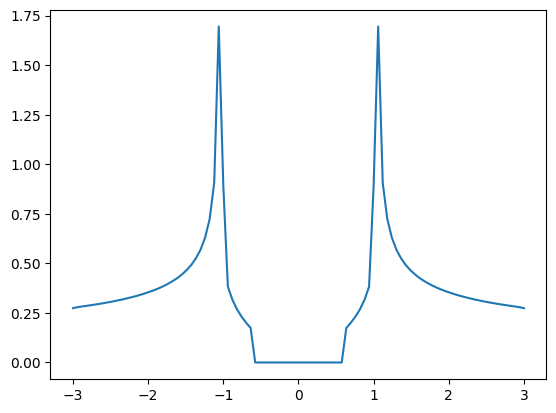

{'Energy': <wannierberri.result.kbandresult.KBandResult object at 0x7a0a2c13c770>}


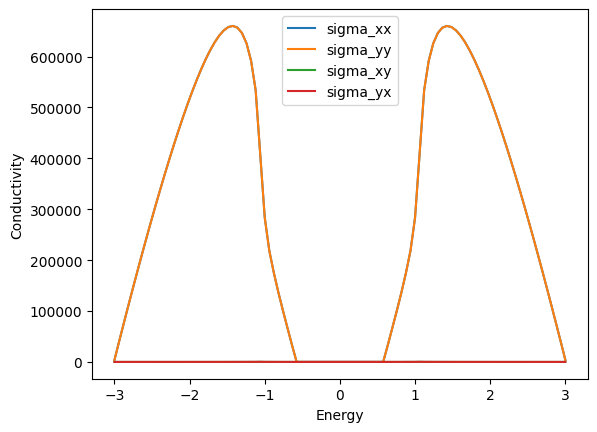

In [17]:
plt.plot(Efermi, results.results["dos"].data, label="DOS")
plt.show()
plt.plot(Efermi, results.results["ohmic"].data[:,0,0], label="sigma_xx")
plt.plot(Efermi, results.results["ohmic"].data[:,1,1], label="sigma_yy")
plt.plot(Efermi, results.results["ohmic"].data[:,0,1], label="sigma_xy")
plt.plot(Efermi, results.results["ohmic"].data[:,1,0], label="sigma_yx")
plt.legend()
plt.xlabel('Energy')
plt.ylabel('Conductivity') 

print (results.results["tabulate"].results)
energies = results.results["tabulate"].results["Energy"].data.reshape(NK, NK,-1)

rec_lattive = system.recip_lattice[:2,:2]

np.savez("energies.npz", energies=energies, rec_lattice=rec_lattive)

(100, 100, 2)


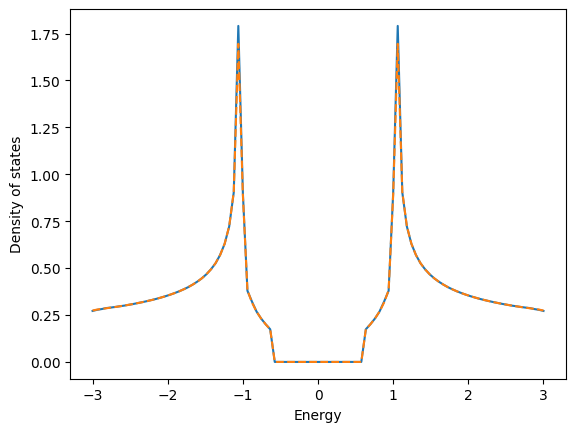

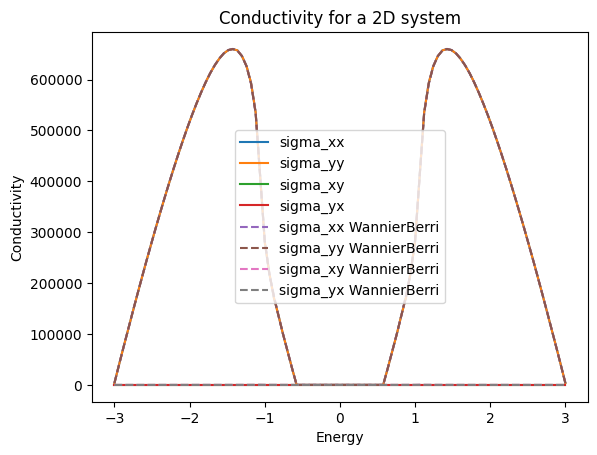

In [29]:
from integrateFermi.contours2D import get_kpoints_and_weights_FS
from wannierberri.factors import factor_ohmic

result_dos =np.load("result-dos_iter-0000.npz")
Efermi = result_dos["Energies_0"]
dos_wb = result_dos["data"]
result_cond = np.load("result-ohmic_iter-0000.npz")
conductivity_wb = result_cond["data"][:,:2,:2] * system.real_lattice[2,2] 
f = np.load("energies.npz")
E = f["energies"][:,:]
print(E.shape)
rec_lattive = f["rec_lattice"]

dos = np.zeros(len(Efermi))
conductivity = np.zeros((len(Efermi), 2, 2))

for ib in range(2):
    for i, e in enumerate(Efermi):
        kpoints, weights, grad = get_kpoints_and_weights_FS(E[:,:,ib], rec_lattive, e, gradient=True)
        dos[i] += np.sum(weights)
        conductivity[i] += np.einsum('i,ia,ib->ab', weights, grad, grad)

conductivity *= factor_ohmic * np.linalg.det(rec_lattive) / (2*np.pi)**2
import matplotlib.pyplot as plt
plt.plot(Efermi, dos)
plt.plot(Efermi, dos_wb, label="DOS WannierBerri", linestyle='dashed')
plt.xlabel('Energy')
plt.ylabel('Density of states')
plt.show()

plt.plot(Efermi, conductivity[:,0,0], label='sigma_xx')
plt.plot(Efermi, conductivity[:,1,1], label='sigma_yy')
plt.plot(Efermi, conductivity[:,0,1], label='sigma_xy')
plt.plot(Efermi, conductivity[:,1,0], label='sigma_yx')
plt.plot(Efermi, conductivity_wb[:,0,0], label='sigma_xx WannierBerri', linestyle='dashed')
plt.plot(Efermi, conductivity_wb[:,1,1], label='sigma_yy WannierBerri', linestyle='dashed')
plt.plot(Efermi, conductivity_wb[:,0,1], label='sigma_xy WannierBerri', linestyle='dashed')
plt.plot(Efermi, conductivity_wb[:,1,0], label='sigma_yx WannierBerri', linestyle='dashed')
plt.legend()
plt.xlabel('Energy')
plt.ylabel('Conductivity')
plt.title(f'Conductivity for a 2D system')
plt.show()

In [7]:
%ls *



energies.npz              result-ohmic_iter-0000.dat  testContours.py
result-dos_iter-0000.dat  result-ohmic_iter-0000.npz  testContoursWB.py
result-dos_iter-0000.npz  result-tabulate.npz         test_contoursWB.ipynb

integrateFermi:
__init__.py  contours2D.py
